# Fantasy Category PCA Exploration

This notebook is a cleaned-up version of the original `Testing-PCA.ipynb`. It keeps the baseball PCA experiments and removes unrelated scratch work, while making the workflow easier to rerun:

- uses the package API instead of the old `stat_scraping` notebook import
- builds hitter and pitcher feature frames explicitly
- standardizes features before PCA
- uses `sklearn` PCA instead of hand-rolled eigenvector sorting
- reports explained variance, loadings, and the players driving each principal component
- keeps plotting code close to the analysis it supports


In [1]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import mlbstatscraping as ss

pd.set_option("display.max_columns", 100)


Matplotlib is building the font cache; this may take a moment.


## Configuration

In [2]:
YEAR = 2022
HITTER_PA_LIMIT = 100
PITCHER_TBF_LIMIT = 100
N_COMPONENTS = 2

HITTER_FEATURE_COLUMNS = [
    "R_per_PA",
    "RBI_per_PA",
    "HR_per_PA",
    "SB_per_PA",
    "AVG",
]

PITCHER_FEATURE_COLUMNS = [
    "ER_per_TBF",
    "SO_per_TBF",
    "BB_per_TBF",
    "HR_per_TBF",
    "H_per_TBF",
]


## PCA Helpers

In [3]:
def run_pca(frame, feature_columns, n_components=N_COMPONENTS):
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(frame[feature_columns])

    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(scaled_features)

    pc_columns = [f"PC{i + 1}" for i in range(n_components)]
    scores_df = frame[["Name", "Team", "Year", *feature_columns]].copy()
    scores_df[pc_columns] = scores

    explained_variance = pd.Series(
        pca.explained_variance_ratio_,
        index=pc_columns,
        name="explained_variance_ratio",
    )
    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_columns,
        columns=pc_columns,
    )

    return scores_df, loadings, explained_variance, pca, scaler


def plot_feature_scatter(frame, x_column, y_column, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(frame[x_column], frame[y_column], s=8, alpha=0.65, color="black")
    ax.set_xlabel(x_column)
    ax.set_ylabel(y_column)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    return ax


def plot_pca_scores(scores_df, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(scores_df["PC1"], scores_df["PC2"], s=8, alpha=0.65, color="black")
    ax.axhline(0, color="lightgray", linewidth=1)
    ax.axvline(0, color="lightgray", linewidth=1)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    return ax


def show_component_extremes(scores_df, component, n=10):
    columns = ["Name", "Team", "Year", component]
    high = scores_df.nlargest(n, component)[columns].assign(direction="high")
    low = scores_df.nsmallest(n, component)[columns].assign(direction="low")
    return pd.concat([high, low], ignore_index=True)


## Load Fangraphs Data

In [4]:
hitting = ss.get_fangraphs_data("hitting", [str(YEAR)])
pitching = ss.get_fangraphs_data("pitching", [str(YEAR)])

print(f"Hitters loaded: {len(hitting)}")
print(f"Pitchers loaded: {len(pitching)}")


Hitters loaded: 1495
Pitchers loaded: 871


## Hitter PCA Frame

The original notebook normalized hitter counting stats by plate appearances. This keeps that core idea, then adds batting average as an already-rate-like fifth feature.


In [5]:
def build_hitter_pca_frame(df, pa_limit=HITTER_PA_LIMIT):
    frame = df.copy()
    numeric_columns = ["PA", "R", "RBI", "HR", "SB", "AVG"]

    for column in numeric_columns:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    frame = frame.loc[frame["PA"] > pa_limit].copy()
    frame["R_per_PA"] = frame["R"] / frame["PA"]
    frame["RBI_per_PA"] = frame["RBI"] / frame["PA"]
    frame["HR_per_PA"] = frame["HR"] / frame["PA"]
    frame["SB_per_PA"] = frame["SB"] / frame["PA"]

    columns = ["Name", "Team", "Year", *HITTER_FEATURE_COLUMNS]
    frame = frame.replace([np.inf, -np.inf], np.nan)
    return frame[columns].dropna().reset_index(drop=True)


hitter_frame = build_hitter_pca_frame(hitting)
print(f"Rows after PA>{HITTER_PA_LIMIT}: {len(hitter_frame)}")
hitter_frame.head()


Rows after PA>100: 469


,Name,Team,Year,R_per_PA,RBI_per_PA,HR_per_PA,SB_per_PA,AVG
0,Marcus Semien,TEX,2022,0.139503,0.114641,0.035912,0.034530,0.248097
1,Freddie Freeman,LAD,2022,0.165254,0.141243,0.029661,0.018362,0.325163
2,Trea Turner,LAD,2022,0.142655,0.141243,0.029661,0.038136,0.297546
3,Francisco Lindor,NYM,2022,0.138810,0.151558,0.036827,0.022663,0.269841
4,Vladimir Guerrero Jr.,TOR,2022,0.127479,0.137394,0.045326,0.011331,0.274295


In [6]:
hitter_frame[HITTER_FEATURE_COLUMNS].describe().T


,count,mean,std,min,25%,50%,75%,max
R_per_PA,469.0,0.111170,0.025536,0.031746,0.094118,0.111369,0.128205,0.207547
RBI_per_PA,469.0,0.105927,0.030420,0.030702,0.086957,0.105455,0.123636,0.240260
HR_per_PA,469.0,0.027360,0.015330,0.000000,0.016129,0.026565,0.036900,0.097403
SB_per_PA,469.0,0.013308,0.016178,0.000000,0.002041,0.007599,0.018797,0.102564
AVG,469.0,0.237459,0.035681,0.123810,0.214022,0.238342,0.261146,0.326454


<Axes: title={'center': 'Hitter run and RBI rates'}, xlabel='R_per_PA', ylabel='RBI_per_PA'>

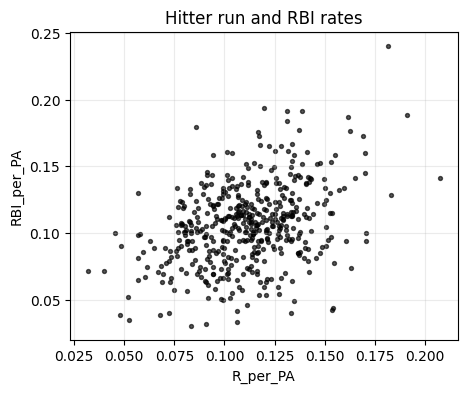

In [7]:
plot_feature_scatter(
    hitter_frame,
    "R_per_PA",
    "RBI_per_PA",
    "Hitter run and RBI rates",
)


## Hitter PCA Results

PCA component signs are arbitrary, so read the loadings as groups of stats that move together rather than as fixed good/bad directions.


In [8]:
hitter_scores, hitter_loadings, hitter_explained, hitter_pca, hitter_scaler = run_pca(
    hitter_frame,
    HITTER_FEATURE_COLUMNS,
)

pd.DataFrame(
    {
        "explained_variance_ratio": hitter_explained,
        "explained_variance_percent": hitter_explained * 100,
    }
)


,explained_variance_ratio,explained_variance_percent
PC1,0.461203,46.120329
PC2,0.257220,25.721963


In [9]:
hitter_loadings


,PC1,PC2
R_per_PA,0.488570,0.405784
RBI_per_PA,0.559489,-0.276817
HR_per_PA,0.534466,-0.308385
SB_per_PA,0.025509,0.774446
AVG,0.402452,0.252673


<Axes: title={'center': 'Hitter PCA scores'}, xlabel='PC1', ylabel='PC2'>

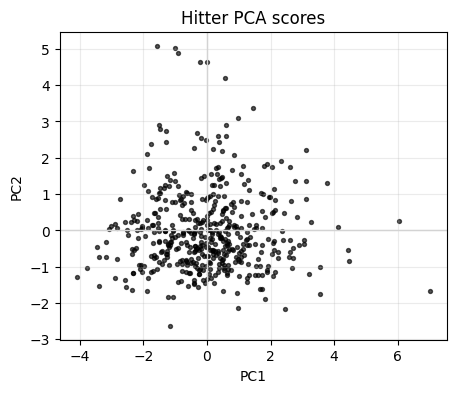

In [10]:
plot_pca_scores(hitter_scores, "Hitter PCA scores")


In [11]:
show_component_extremes(hitter_scores, "PC1")


,Name,Team,Year,PC1,direction
0,Matt Carpenter,NYY,2022,7.008986,high
1,Aaron Judge,NYY,2022,6.040214,high
2,Mike Trout,LAA,2022,4.475071,high
3,Yordan Alvarez,HOU,2022,4.454292,high
4,Paul Goldschmidt,STL,2022,4.110373,high
5,Jazz Chisholm Jr.,MIA,2022,3.769252,high
6,Albert Pujols,STL,2022,3.565651,high
7,Pete Alonso,NYM,2022,3.554148,high
8,Manny Machado,SDP,2022,3.269842,high
9,Danny Jansen,TOR,2022,3.214027,high


In [12]:
show_component_extremes(hitter_scores, "PC2")


,Name,Team,Year,PC2,direction
0,Bubba Thompson,TEX,2022,5.086234,high
1,Jon Berti,MIA,2022,5.012470,high
2,Luke Williams,- - -,2022,4.883232,high
3,Nate Eaton,KCR,2022,4.644828,high
4,Eli White,TEX,2022,4.639587,high
5,Dylan Moore,SEA,2022,4.189987,high
6,Jake McCarthy,ARI,2022,3.369556,high
7,Sam Haggerty,SEA,2022,3.090059,high
8,Tommy Edman,STL,2022,2.899216,high
9,Tyler Wade,LAA,2022,2.897878,high


## Pitcher PCA Frame

The pitcher experiment follows the same rate-stat approach as the original scratch cells: events are normalized by batters faced before PCA.


In [13]:
def build_pitcher_pca_frame(df, tbf_limit=PITCHER_TBF_LIMIT):
    frame = df.copy()
    numeric_columns = ["TBF", "ER", "SO", "BB", "HR", "H"]

    for column in numeric_columns:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    frame = frame.loc[frame["TBF"] > tbf_limit].copy()
    frame["ER_per_TBF"] = frame["ER"] / frame["TBF"]
    frame["SO_per_TBF"] = frame["SO"] / frame["TBF"]
    frame["BB_per_TBF"] = frame["BB"] / frame["TBF"]
    frame["HR_per_TBF"] = frame["HR"] / frame["TBF"]
    frame["H_per_TBF"] = frame["H"] / frame["TBF"]

    columns = ["Name", "Team", "Year", *PITCHER_FEATURE_COLUMNS]
    frame = frame.replace([np.inf, -np.inf], np.nan)
    return frame[columns].dropna().reset_index(drop=True)


pitcher_frame = build_pitcher_pca_frame(pitching)
print(f"Rows after TBF>{PITCHER_TBF_LIMIT}: {len(pitcher_frame)}")
pitcher_frame.head()


Rows after TBF>100: 518


,Name,Team,Year,ER_per_TBF,SO_per_TBF,BB_per_TBF,HR_per_TBF,H_per_TBF
0,Sandy Alcantara,MIA,2022,0.065463,0.233634,0.056433,0.018059,0.196388
1,Aaron Nola,PHI,2022,0.091698,0.291202,0.035936,0.023544,0.208178
2,Miles Mikolas,STL,2022,0.091925,0.190062,0.048447,0.031056,0.211180
3,Corbin Burnes,MIL,2022,0.082811,0.304893,0.063990,0.028858,0.180678
4,Framber Valdez,HOU,2022,0.076179,0.234583,0.081016,0.013301,0.200726


In [14]:
pitcher_frame[PITCHER_FEATURE_COLUMNS].describe().T


,count,mean,std,min,25%,50%,75%,max
ER_per_TBF,518.0,0.104049,0.030923,0.028571,0.083028,0.101629,0.125000,0.244755
SO_per_TBF,518.0,0.227321,0.057138,0.106195,0.187823,0.223140,0.261830,0.502128
BB_per_TBF,518.0,0.085763,0.027911,0.022222,0.064804,0.084078,0.102454,0.180952
HR_per_TBF,518.0,0.027954,0.013064,0.000000,0.019418,0.027112,0.034981,0.083916
H_per_TBF,518.0,0.215140,0.036000,0.109804,0.191287,0.213538,0.241286,0.333333


<Axes: title={'center': 'Pitcher earned-run and strikeout rates'}, xlabel='ER_per_TBF', ylabel='SO_per_TBF'>

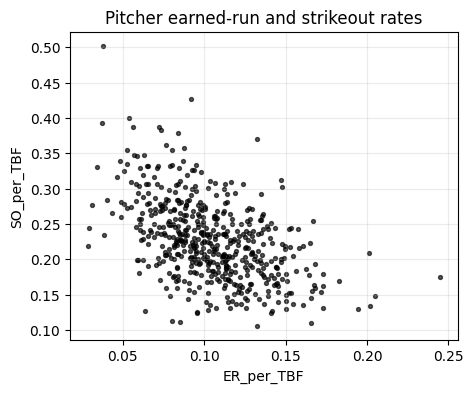

In [15]:
plot_feature_scatter(
    pitcher_frame,
    "ER_per_TBF",
    "SO_per_TBF",
    "Pitcher earned-run and strikeout rates",
)


## Pitcher PCA Results

In [16]:
pitcher_scores, pitcher_loadings, pitcher_explained, pitcher_pca, pitcher_scaler = run_pca(
    pitcher_frame,
    PITCHER_FEATURE_COLUMNS,
)

pd.DataFrame(
    {
        "explained_variance_ratio": pitcher_explained,
        "explained_variance_percent": pitcher_explained * 100,
    }
)


,explained_variance_ratio,explained_variance_percent
PC1,0.497716,49.771604
PC2,0.221747,22.174666


In [17]:
pitcher_loadings


,PC1,PC2
ER_per_TBF,0.542083,0.320183
SO_per_TBF,-0.478165,-0.021847
BB_per_TBF,-0.104592,0.918020
HR_per_TBF,0.403279,0.080547
H_per_TBF,0.551299,-0.218534


<Axes: title={'center': 'Pitcher PCA scores'}, xlabel='PC1', ylabel='PC2'>

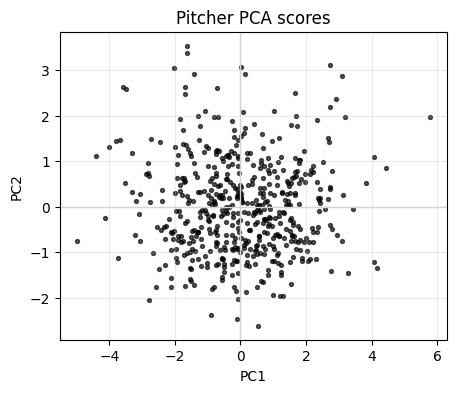

In [18]:
plot_pca_scores(pitcher_scores, "Pitcher PCA scores")


In [19]:
show_component_extremes(pitcher_scores, "PC1")


,Name,Team,Year,PC1,direction
0,Elvin Rodriguez,DET,2022,5.770528,high
1,Kohei Arihara,TEX,2022,4.436601,high
2,Bruce Zimmermann,BAL,2022,4.176428,high
3,Michael Pineda,DET,2022,4.085425,high
4,Dallas Keuchel,- - -,2022,4.078454,high
5,Spencer Howard,TEX,2022,3.818860,high
6,T.J. McFarland,STL,2022,3.439579,high
7,Hyun-Jin Ryu,TOR,2022,3.267648,high
8,Justin Dunn,CIN,2022,3.189481,high
9,Zach Logue,OAK,2022,3.132464,high


In [20]:
show_component_extremes(pitcher_scores, "PC2")


,Name,Team,Year,PC2,direction
0,Touki Toussaint,LAA,2022,3.537561,high
1,Aroldis Chapman,NYY,2022,3.387273,high
2,Heath Hembree,- - -,2022,3.102845,high
3,Josh Staumont,KCR,2022,3.068857,high
4,Amir Garrett,KCR,2022,3.053215,high
5,Ryan Pepiot,LAD,2022,2.925978,high
6,Chase Anderson,CIN,2022,2.916414,high
7,Sean Newcomb,- - -,2022,2.868378,high
8,Tyler Matzek,ATL,2022,2.633434,high
9,Jose Cisnero,DET,2022,2.621511,high


## Easy Next Experiments

- Run several seasons at once, for example `YEARS = ["2021", "2022", "2023", "2024"]`, and compare component stability by year.
- Use `advanced=True` in `get_fangraphs_data` and add Statcast or plate-discipline features.
- Fit PCA on one season and transform later seasons with the same scaler and PCA object.
- Cluster players in PCA space to find similar fantasy profiles.
